In [28]:
import pandas as pd
import missingno as mgno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

работать будем с датасетом Boston_housing_pricing

In [2]:
df= pd.read_csv('Boston.csv',index_col= 0)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
df.info

<bound method DataFrame.info of         crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
1    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
2    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
3    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
4    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
5    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
502  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
503  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
504  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
505  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
506  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio   black  lstat  medv  
1       15.3  396.90   4.98  24.0  
2       17.8  396.9

In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64


<Axes: >

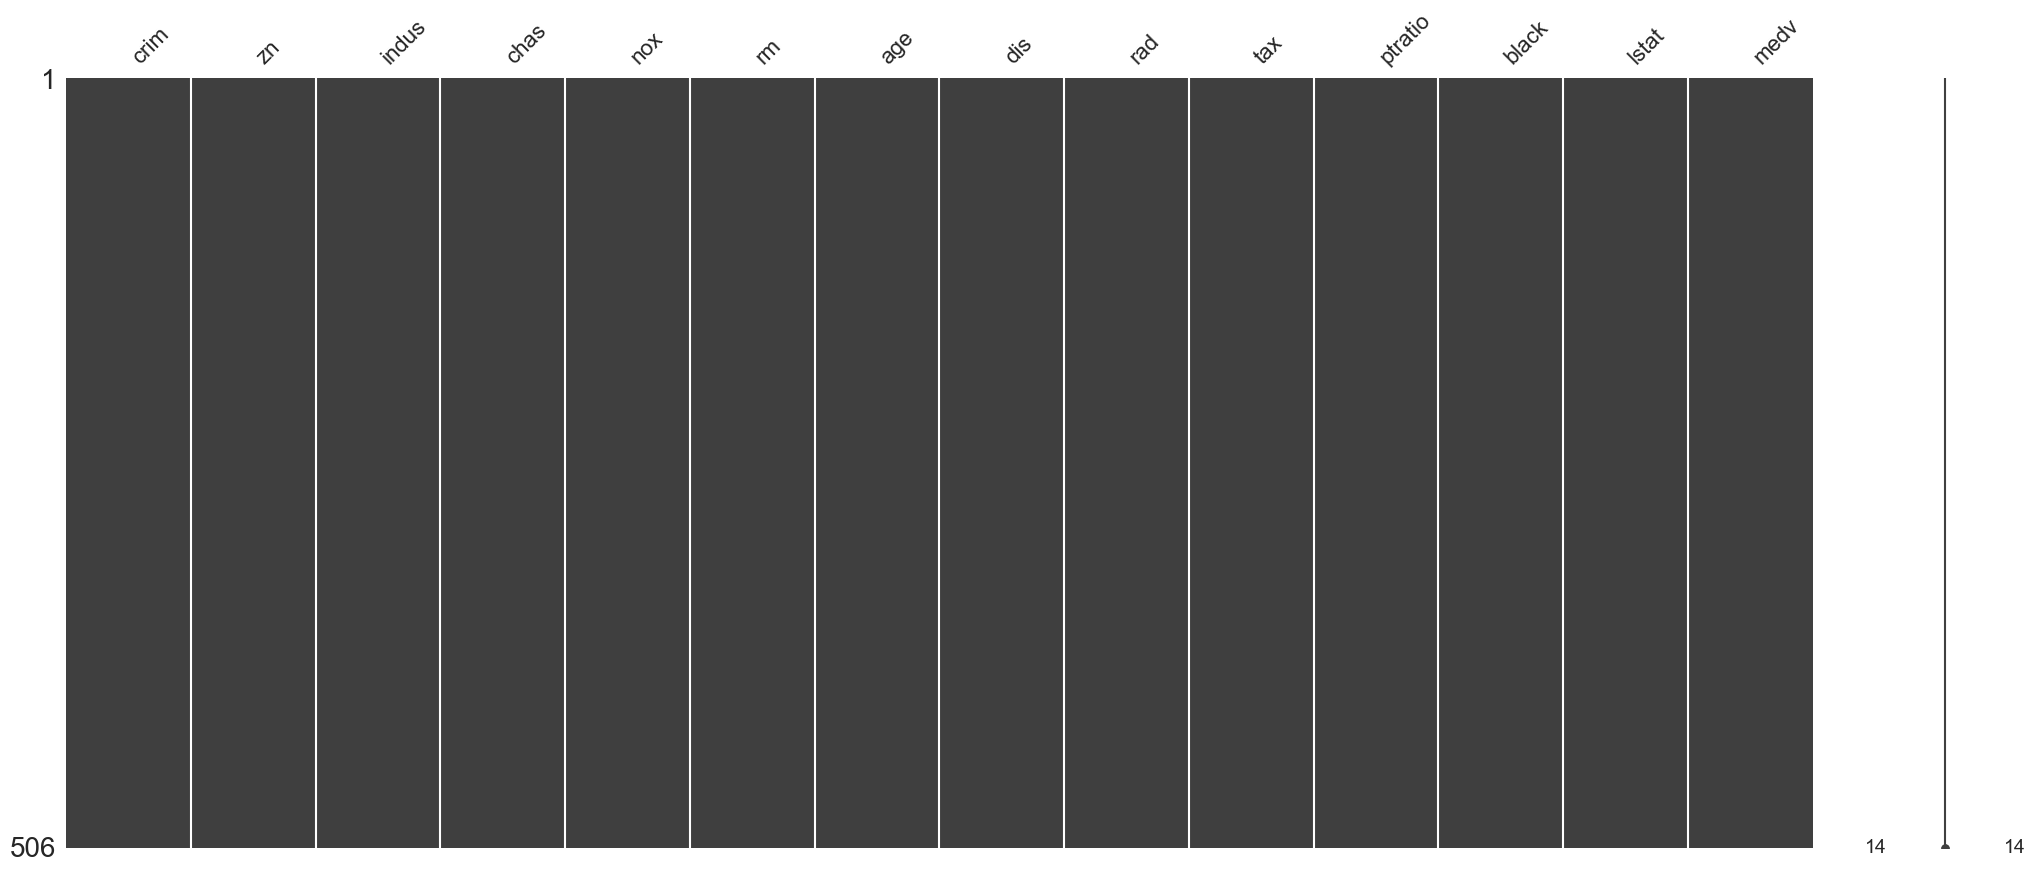

In [5]:
print(df.isnull().sum())
mgno.matrix(df)

как мы  можем заметить в нашем датасете нет ни единого пропуска

<Axes: >

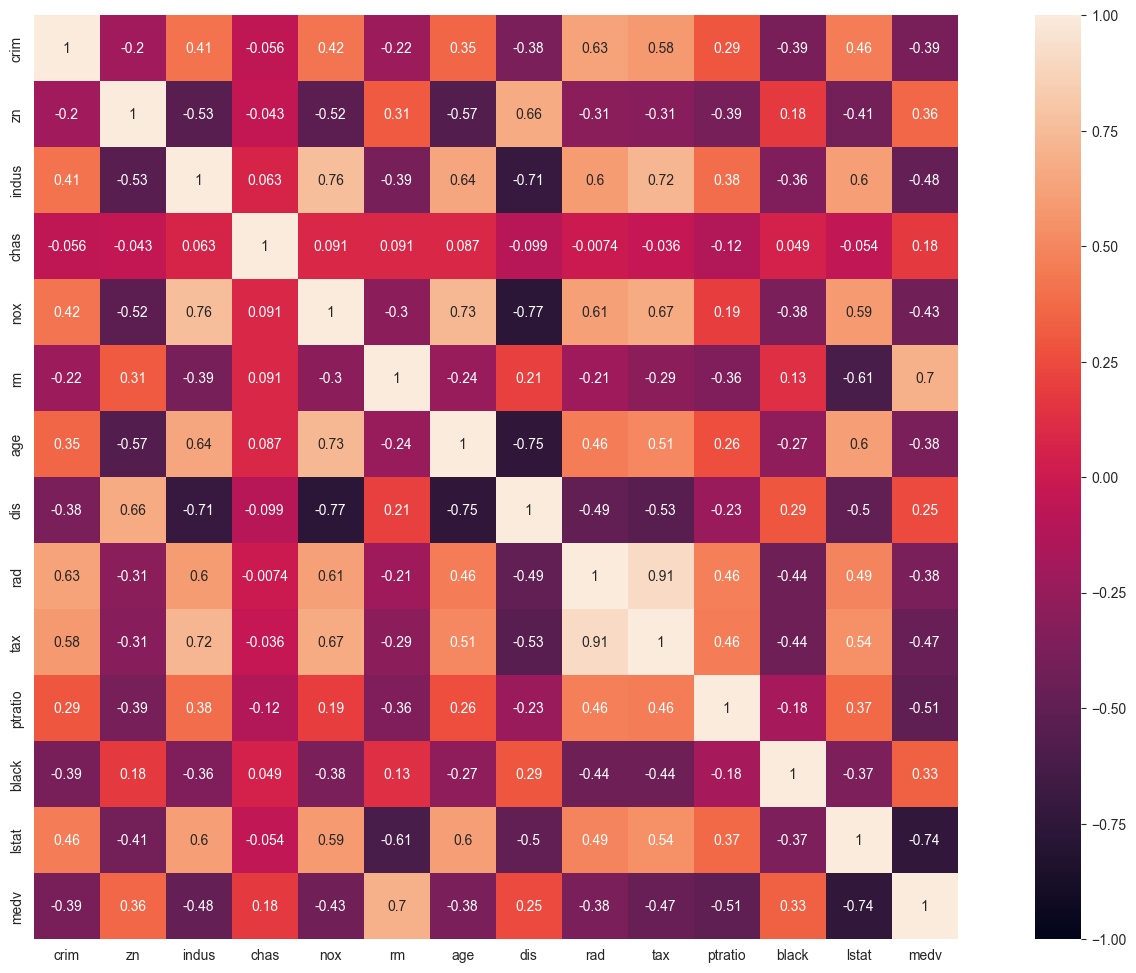

In [6]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, 
            annot=True,        
            vmin=-1, vmax=1,
            square=True 
           )


будем предсказывать стоимость дома MEDV(стоимость дома в 1000), сначала попробуем обычную линейную регрессию потом попробуем ращные другие методы

In [7]:
x = df.drop(columns = 'medv').
y = df['medv']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.2, random_state=42)

In [26]:
j_pipe = Pipeline([
    ('scaler' , MinMaxScaler()),
    ('model', LinearRegression())
])

j_pipe.fit(x_train,y_train)

y_pred1 = j_pipe.predict(x_test)
y_pred_train = j_pipe.predict(x_train)
print(f"MAPE : {mean_absolute_percentage_error(y_test,y_pred1):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred1):.4f}")
print(f"R2(test) : {r2_score(y_test,y_pred1):.4f}")
print(f"R2(train) : {r2_score(y_train,y_pred_train):.4f}")

MAPE : 0.1687
MSE : 24.2911
R2(test) : 0.6688
R2(train) : 0.7509


как мы можем заметить показатели не сильно впечатляют, попробуем немного изменить наш подход

In [37]:
ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(2)),
    ('model', Ridge())
])

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(x_train, y_train)

best_ridge = ridge_grid.best_estimator_


y_pred2 = true_ridge.predict(x_test)
y_pred_train2 = true_ridge.predict(x_train)
print(f"MAPE : {mean_absolute_percentage_error(y_test,y_pred2):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred2):.4f}")
print(f"R2(test) : {r2_score(y_test,y_pred2):.4f}")
print(f"R2(train) : {r2_score(y_train,y_pred_train2):.4f}")

MAPE : 0.1157
MSE : 13.3433
R2(test) : 0.8180
R2(train) : 0.9279


In [45]:
Lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(2)),
    ('model', Lasso(max_iter=7500))
])

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(Lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(x_train, y_train)

best_lasso = lasso_grid.best_estimator_


y_pred_lasso_train = best_lasso.predict(x_train)
y_pred_lasso_test = best_lasso.predict(x_test)

print(f"MAPE : {mean_absolute_percentage_error(y_test,y_pred_lasso_test):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred_lasso_test):.4f}")
print(f"R2(test) : {r2_score(y_test,y_pred_lasso_test):.4f}")
print(f"R2(train) : {r2_score(y_train,y_pred_lasso_train):.4f}")


MAPE : 0.1190
MSE : 13.7709
R2(test) : 0.8122
R2(train) : 0.9006
